In [62]:
# Import libraries
import ast
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [63]:
# Load dataset
df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/preparation/tokenverses.csv", encoding='utf-8-sig')
print("Initial shape:", df.shape)

Initial shape: (39005, 17)


In [64]:
df = df.dropna(subset=["tokens"])
print("Shape after dropping NaN:", df.shape)

Shape after dropping NaN: (39005, 17)


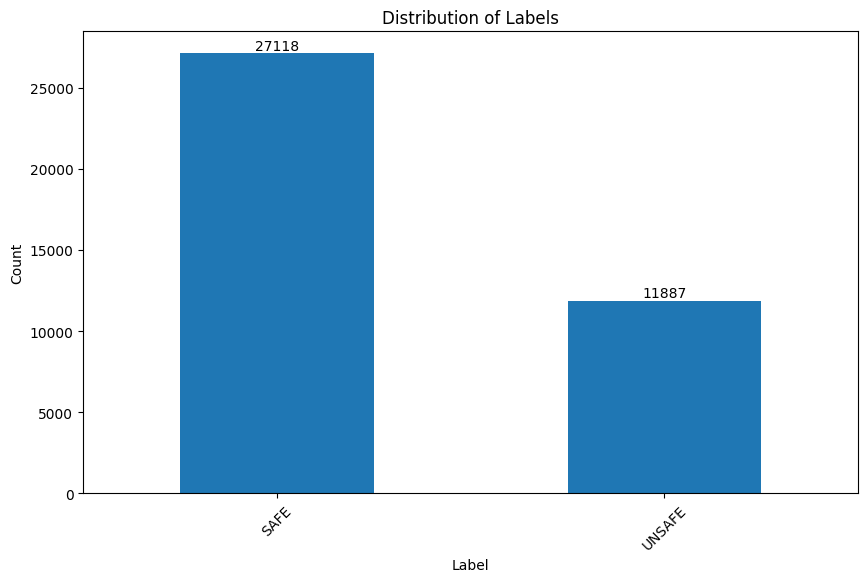

In [113]:
# Distribution of labels
label_counts = df['label'].value_counts()
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)

for i, value in enumerate(label_counts):
    plt.text(i, value, str(value), ha='center', va='bottom')
    
plt.show()

(6187, 4)


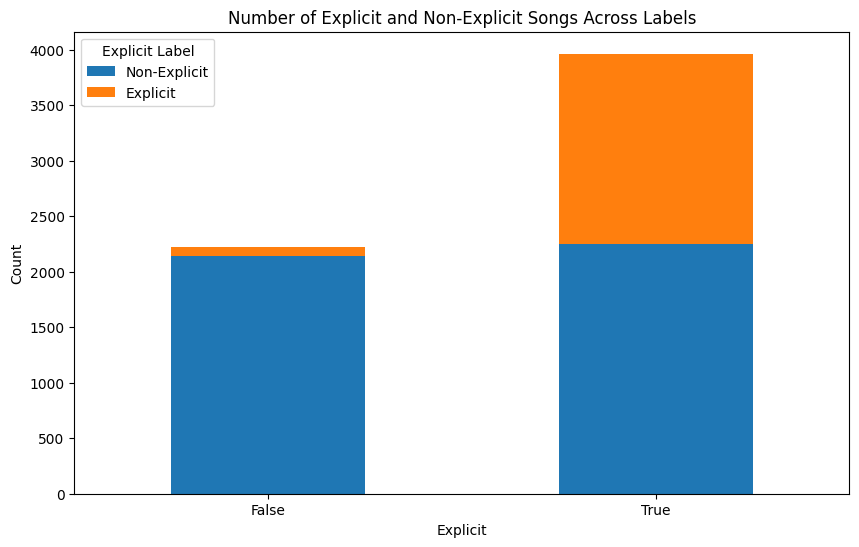

In [121]:
# Create a song-level DataFrame
df_song_level = df.groupby('song_id').agg({
    'track_name': 'first',      # song name
    'explicit': 'first',        # same for all rows
    'label': lambda x: (x.str.upper() == 'UNSAFE').any()  # True if any UNSAFE
}).reset_index()

print(df_song_level.shape)

# Plot the distribution of explicit and non-explicit songs across safe and unsafe labels
explicit_counts = df_song_level.groupby(['label', 'explicit']).size().unstack(fill_value=0)
explicit_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Number of Explicit and Non-Explicit Songs Across Labels')
plt.xlabel('Explicit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Explicit Label', labels=['Non-Explicit', 'Explicit'])
plt.show()

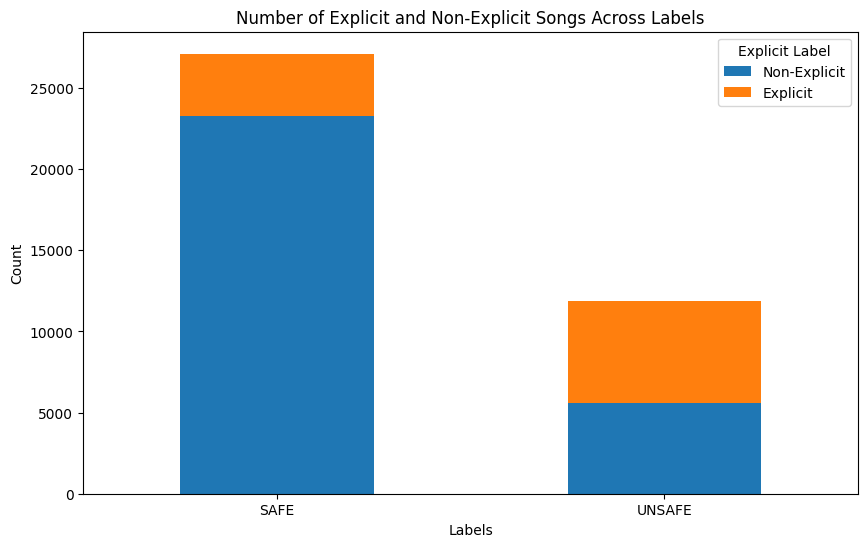

In [122]:
# Number of safe and unsafe songs across explicit and non-explicit song
explicit_counts = df.groupby(['label', 'explicit']).size().unstack(fill_value=0)
explicit_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Number of Explicit and Non-Explicit Songs Across Labels')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Explicit Label', labels=['Non-Explicit', 'Explicit'])
plt.show()

In [67]:
# Distribution of length of verses (tokens column)
# Parse list-like strings and count the number of tokens in each row
def parse_tokens(value):
    if isinstance(value, (list, tuple, set)):
        return list(value)
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, (list, tuple, set)):
                return list(parsed)
        except (ValueError, SyntaxError):
            pass
        return value.split()
    return list(value) if hasattr(value, '__iter__') else [value]
df['verse_length'] = df['tokens'].apply(
    lambda value: len([
        token for token in parse_tokens(value)
        if re.search(r"\w", token)  # keeps only tokens with letters/numbers
    ])
)
print(df['verse_length'].describe())

# Find upper bound for outliers using IQR
Q1 = df['verse_length'].quantile(0.25)
Q3 = df['verse_length'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"\nUpper bound for outliers: {upper_bound}")

count    39005.000000
mean        48.076093
std         42.758429
min          0.000000
25%         24.000000
50%         39.000000
75%         60.000000
max       1291.000000
Name: verse_length, dtype: float64

Upper bound for outliers: 114.0


In [117]:
no_outliers = df[df['verse_length'] > 114]
no_outliers.to_csv("C:/Users/User/Documents/devanasokan_fyp/preparation/no_outliers.csv", index=False, encoding='utf-8-sig')
print(no_outliers.shape)

(2209, 18)


(36796, 18)


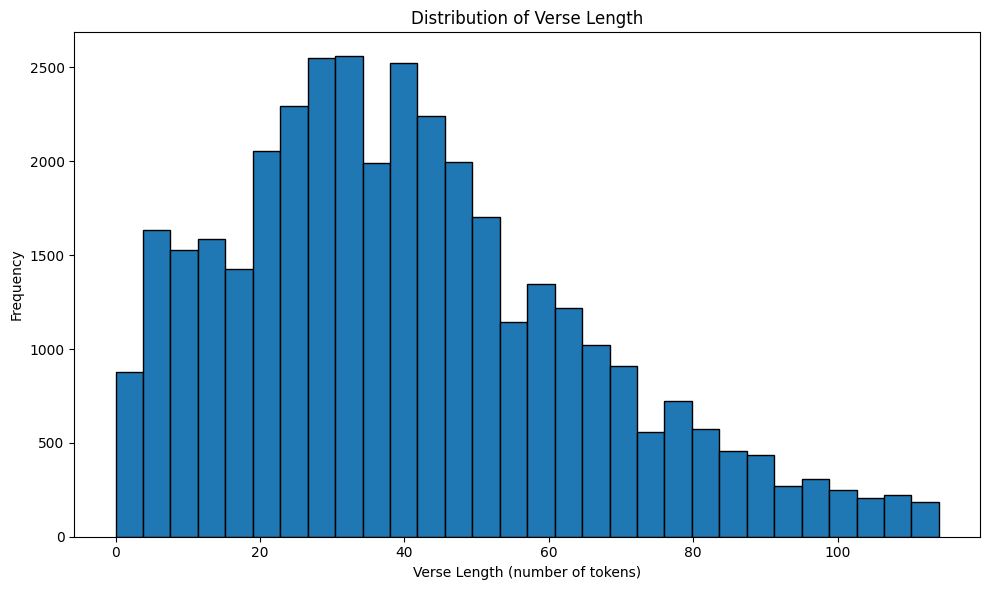

In [95]:
# Create a new DataFrame below the upper bound
no_outliers = df[df['verse_length'] <= 114]
print(no_outliers.shape)

# Plot distribution of verse length
plt.figure(figsize=(10, 6))
plt.hist(no_outliers['verse_length'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Verse Length')
plt.xlabel('Verse Length (number of tokens)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

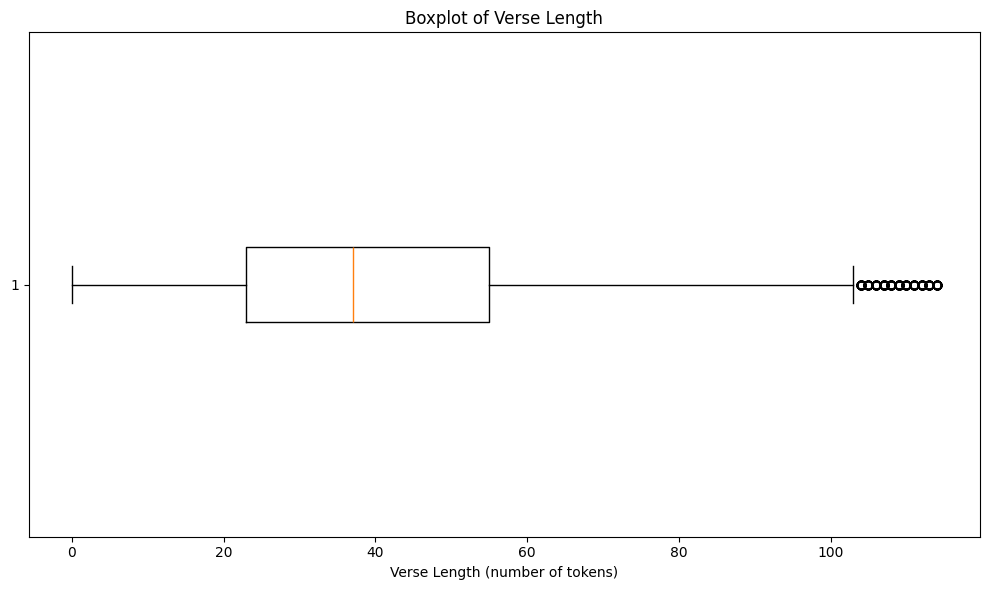

In [96]:
# Boxplot for verse length
plt.figure(figsize=(10, 6))
plt.boxplot(no_outliers['verse_length'].dropna(), vert=False)
plt.title('Boxplot of Verse Length')
plt.xlabel('Verse Length (number of tokens)')
plt.ylabel('')  # Hide y-axis label
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

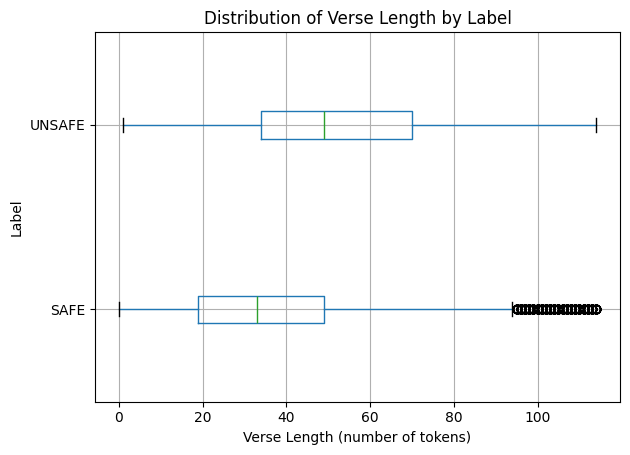

In [97]:
# Distribution of verse length by label
plt.figure(figsize=(10, 6))
no_outliers.boxplot(column='verse_length', by='label', vert=False)
plt.title('Distribution of Verse Length by Label')
plt.suptitle('')
plt.xlabel('Verse Length (number of tokens)')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

In [ ]:
safe_tokens = df[df['label'].str.upper() == 'SAFE']['tokens'] \
    .dropna().apply(parse_tokens)

unsafe_tokens = df[df['label'].str.upper() == 'UNSAFE']['tokens'] \
    .dropna().apply(parse_tokens)

safe_text = ' '.join(' '.join(tokens) for tokens in safe_tokens if tokens)
unsafe_text = ' '.join(' '.join(tokens) for tokens in unsafe_tokens if tokens)

safe_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False
).generate(safe_text)

unsafe_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False
).generate(unsafe_text)

In [107]:
# Generate word cloud for safe and unsafe songs
safe_tokens = df[df['label'].str.upper() == 'SAFE']['tokens'].dropna().apply(parse_tokens)
unsafe_tokens = df[df['label'].str.upper() == 'UNSAFE']['tokens'].dropna().apply(parse_tokens)
safe_text = ' '.join(' '.join(tokens) for tokens in safe_tokens if tokens)
unsafe_text = ' '.join(' '.join(tokens) for tokens in unsafe_tokens if tokens)

if not safe_text or not unsafe_text:
    raise ValueError('No tokens found for safe or unsafe word clouds after filtering.')
safe_wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(safe_text)
unsafe_wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(unsafe_text)

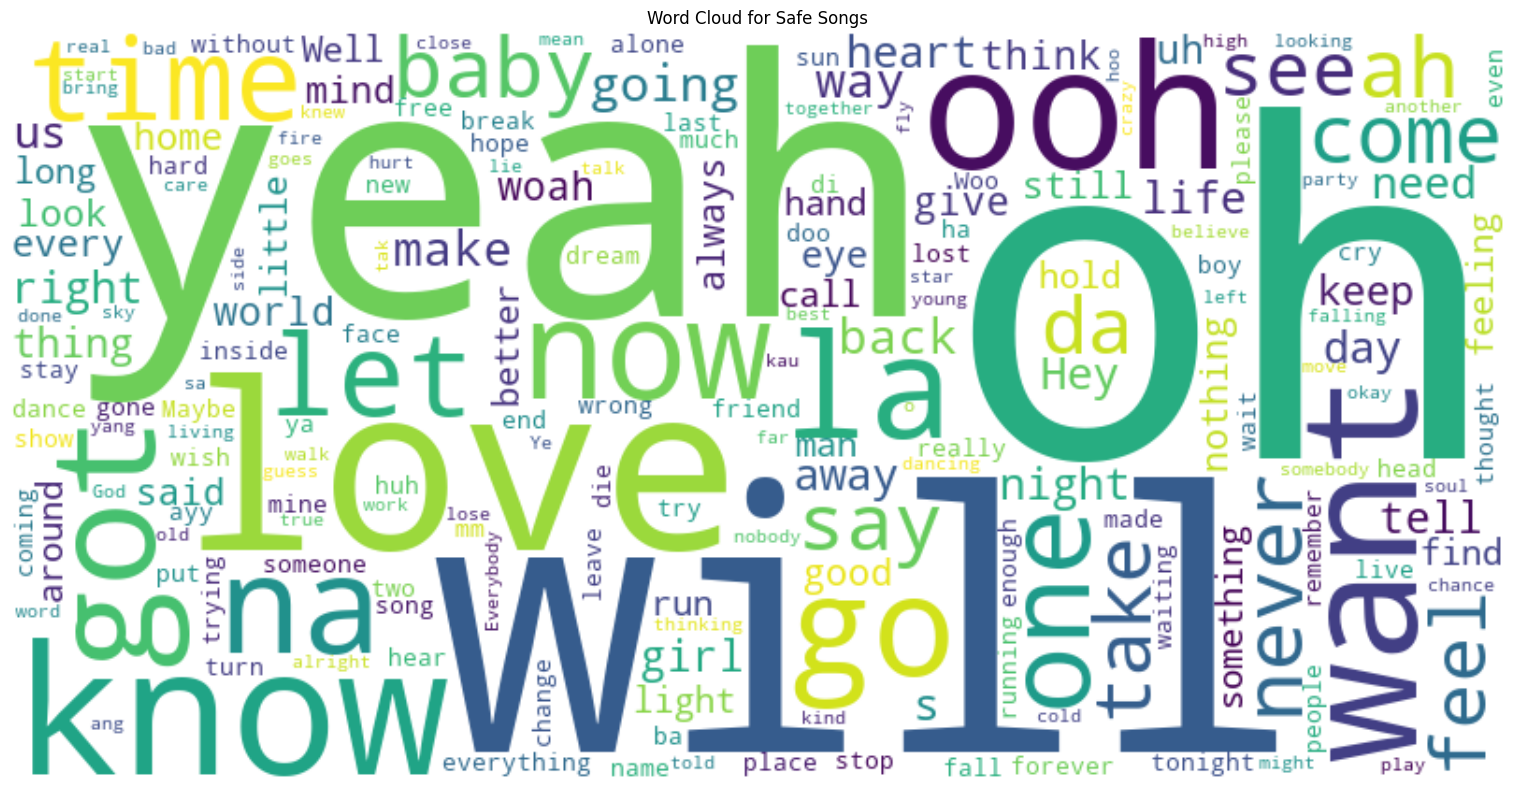

In [ ]:
# Plot word cloud for safe songs
plt.figure(figsize=(16, 8))
plt.imshow(safe_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Safe Songs')
plt.axis('off')
plt.tight_layout()
plt.show()

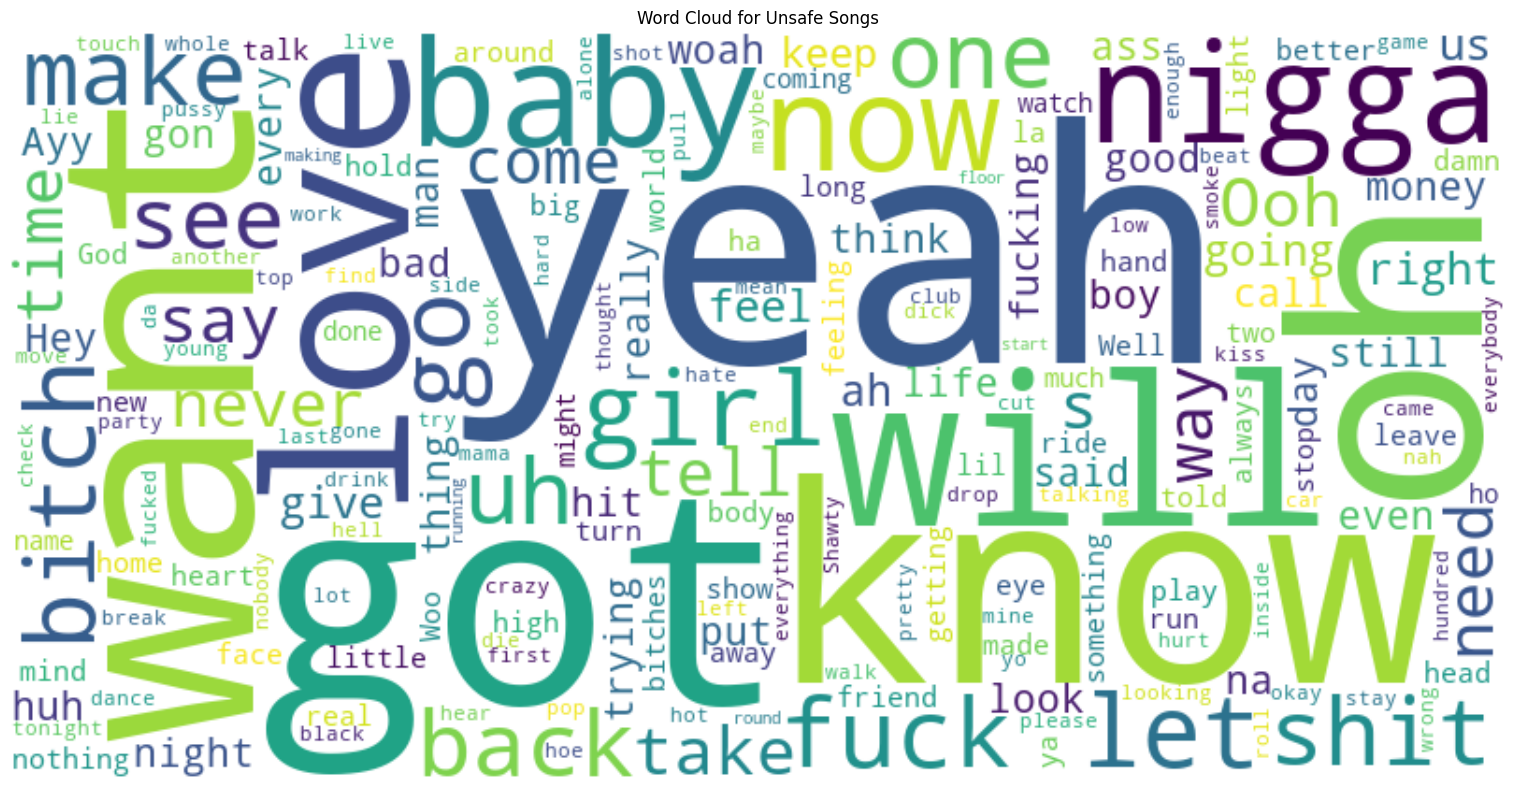

In [110]:
# Plot word cloud for unsafe songs
plt.figure(figsize=(16, 8))
plt.imshow(unsafe_wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Unsafe Songs')
plt.axis('off')
plt.tight_layout()
plt.show()